In [1]:
import plotly
from plotly.graph_objs import Scatter, Layout
import numpy as np
import os
import pandas as pd
import plotly.graph_objects as go
from plotly.offline import plot

%matplotlib inline

In [2]:
discount = 0.02
ConsiderTC = 1
ConsiderMB = 1
informal = 0.0
scenario = 'val'
file_tag = 'ALL'

In [3]:
# codemap = pd.read_csv('codemaps.csv')
countries_info = pd.read_csv('data/countrycode.csv', encoding='utf-8-sig')
countries_info = countries_info[['Country Code', 'Region', 'Income group', 'WBCountry', 'country']]
codemap = countries_info.dropna()

In [4]:
# df = pd.read_csv('imputation/aggregated_results_imputated_%s.csv'%(discount))
result_path = f'results/aggregate_results_imputed_{file_tag}.csv'
if not os.path.exists(result_path):
    result_path = 'results/aggregate_results_imputed.csv'
df_input = pd.read_csv(result_path)
df = df_input[(df_input['discount']==discount)&
                (df_input['ConsiderTC']==ConsiderTC)&
                (df_input['ConsiderMB']==ConsiderMB)&
                (df_input['informal']==informal)&
                (df_input['scenario']==scenario)]

df.head()
df = df.groupby('Country Code').sum()
df = df.reset_index()

In [5]:
test_df = df.copy()
test_df = df.sort_values(by='tax')

In [6]:
test_df

,Country Code,scenario,ConsiderTC,ConsiderMB,informal,discount,GDPloss,tax,pc_loss,disease
108,LUX,val,1,1,0.0,0.02,1.995748,0.000835,2790.855803,ASCVD
41,COM,val,1,1,0.0,0.02,0.091125,0.000981,78.120922,ASCVD
131,NGA,val,1,1,0.0,0.02,39.738465,0.001319,133.272469,ASCVD
93,KEN,val,1,1,0.0,0.02,14.691263,0.001326,201.595049,ASCVD
172,SWZ,val,1,1,0.0,0.02,0.433168,0.001464,306.693714,ASCVD
...,...,...,...,...,...,...,...,...,...,...
107,LTU,val,1,1,0.0,0.02,30.529167,0.008147,12756.296296,ASCVD
178,TJK,val,1,1,0.0,0.02,19.419209,0.009629,1521.769516,ASCVD
54,EGY,val,1,1,0.0,0.02,581.756853,0.009888,4447.411941,ASCVD
17,BGR,val,1,1,0.0,0.02,71.132357,0.013109,11563.627771,ASCVD


In [7]:
df['Country Code'].unique(), len(df['Country Code'].unique())

(array(['AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ASM', 'ATG',
        'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR',
        'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB',
        'BRN', 'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV',
        'CMR', 'COD', 'COG', 'COK', 'COL', 'COM', 'CPV', 'CRI', 'CUB',
        'CYP', 'CZE', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU',
        'EGY', 'ERI', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'FRA', 'FSM',
        'GAB', 'GBR', 'GEO', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC',
        'GRD', 'GRL', 'GTM', 'GUM', 'GUY', 'HND', 'HRV', 'HTI', 'HUN',
        'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM',
        'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR',
        'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LKA', 'LSO', 'LTU',
        'LUX', 'LVA', 'MAR', 'MCO', 'MDA', 'MDG', 'MDV', 'MEX', 'MHL',
        'MKD', 'MLI', 'MLT', 'MMR', 'MNE', 'MNG', 'MNP', 'MOZ', 'MRT',
      

## Economic burden

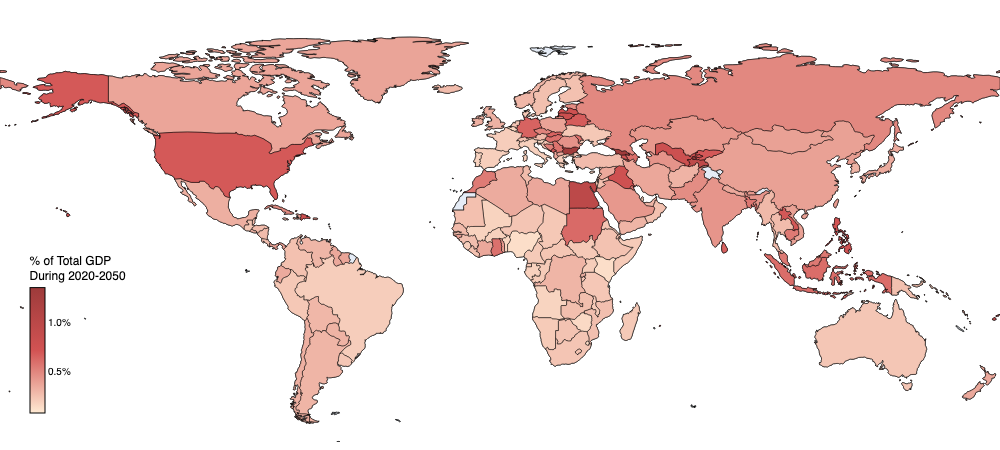

In [ ]:
fig = go.Figure(data=go.Choropleth(
        locations = df['Country Code'],
        z = df['tax']*100,
        colorscale = [[0,"rgb(158, 59, 59)"],
                      [0.5,"rgb(210, 83, 83)"],
                      # [0.25,"rgb(234, 123, 123)"],
                      [1,"rgb(255, 234, 211)"]],
        reversescale = True,
        colorbar_title='% of Total GDP<br>During 2020-2050<br>',
        autocolorscale = False,
        marker = dict(
            line = dict (
                color = 'rgb(0,0,0)',
                width = 0.5
            ) ),
        # colorbar_title='%',
        colorbar = dict(
            len=0.4,
            thickness = 15,
            tick0= 0,
            tickmode='array',
            outlinewidth=1,
            outlinecolor='rgb(0,0,0)',
            tickvals= [0.5, 1],
            ticktext=['0.5%','1.0%']
        ),
            
))
fig.update_layout(
    font=dict(
        # family="Courier New, monospace",
        family="Helvetica",
        size=10,
        color='black'
        # color="#7f7f7f"
    ),
#     title = 'Economic Burden of Road Injuries During 2020-2050',
    geo = dict(
        showframe = False,
        showcoastlines = True,
        coastlinecolor = "rgb(0,0,0)",
        coastlinewidth = 0.5,
        showcountries = True,
        countrycolor = "rgb(0, 0, 0)",
        countrywidth = 0.5,
        showlakes = False,
        projection_type='equirectangular',
        lataxis_range=[-58, 90],
    ),
    margin = {'l':0,'r':0,'t':0,'b':0}

)

fig.data[0].colorbar.x=0.02
fig.data[0].colorbar.y=0.26
fig.update_layout(
    width=1000, height=450,
    margin=dict(l=0, r=0, t=0, b=0)
    )
fig.show(renderer='png')

fig.write_image("figures/figure_1(b).pdf")
fig.write_image("figures/figure_1(b).svg")
fig.write_image("figures/figure_1(b).png", scale=3)

In [29]:
df['logGDPloss'] = df['GDPloss'].apply(np.log10)

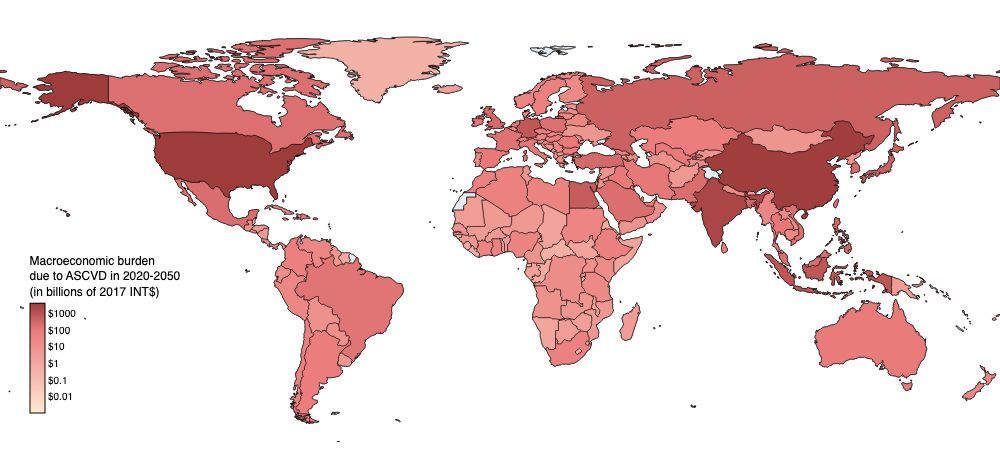

In [31]:
fig = go.Figure(data=go.Choropleth(
        locations = df['Country Code'],
        z = df['logGDPloss'],
        colorscale = [[0,"rgb(158, 59, 59)"],
                      # [0.25,"rgb(210, 83, 83)"],
                      [0.25,"rgb(234, 123, 123)"],
                      [1,"rgb(255, 234, 211)"]],
        reversescale=True,
        # colorscale = 'Blues', 
        autocolorscale = False,
        marker = dict(
            line = dict (
                color = 'rgb(0,0,0)',
                width = 0.5
            ) ),
        # colorbar_title='$Billion',
        colorbar_title='Macroeconomic burden<br>due to ASCVD in 2020-2050<br>(in billions of 2017 INT$)<br>',
        colorbar = dict(
            len = 0.4,
            thickness = 15,
            tick0= 0,
            tickmode='array',
            outlinewidth=1,
            outlinecolor='rgb(0,0,0)',
            tickvals= [-2,-1,0,1,2,3],
            ticktext=['$0.01','$0.1','$1','$10','$100','$1000']),
))
fig.update_layout(
    font=dict(
        family="Helvetica",
        size=10,
        color='black'
    ),
    margin = {'l':0,'r':0,'t':0,'b':0},
    
    geo = dict(
        showframe = False,
        showcoastlines = True,
        coastlinecolor = "rgb(0,0,0)",
        coastlinewidth = 0.5,
        showcountries = True,
        countrycolor = "rgb(0, 0, 0)",
        countrywidth = 0.5,
        showlakes = False,
        projection_type='equirectangular',
        lataxis_range=[-58, 90],
    )
)

fig.data[0].colorbar.x=0.02
fig.data[0].colorbar.y=0.26
fig.update_layout(
    width=1000, height=450,
    margin=dict(l=0, r=0, t=0, b=0)
    )
fig.show(renderer='png')

fig.write_image("figures/figure_1(a).pdf")
fig.write_image("figures/figure_1(a).svg")
fig.write_image("figures/figure_1(a).png", scale=3)

## Supplementary Figures